changed followings from exp1 to suppress reasoning output   
- add `suffix_prompt='<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>'` to training text.  
- loss calculation part : `<|message|><|end|><|start|>assistant<|channel|>final<|message|>[CATEGORY ANSWER TEXT]`  

In [1]:
!nvidia-smi

Sun Sep 14 14:05:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.64.01              Driver Version: 576.88         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:02:00.0 Off |                  N/A |
|  0%   49C    P8             19W /  575W |       0MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
import transformers
from datasets import load_dataset
import datasets as hf_datasets
from unsloth import FastLanguageModel
from peft import get_peft_model, LoraConfig, TaskType
import bitsandbytes as bnb
from fastprogress import progress_bar as pb
import matplotlib.pyplot as plt

/tmp/ipykernel_4697/3521801710.py:7: UserWarning: WARNING: Unsloth should be imported before transformers to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


## Configs

In [2]:
device = 'cuda'

N_EPOCHS = 10
TRAIN_BATCH_SIZE = TEST_BATCH_SIZE = 4
LR = 1e-4
WEIGHT_DECAY = 1e-2

USE_AMP = True
AMP_DTYPE = torch.bfloat16

TEXT_PADDING_MAX_LENGTH = 500

## Model & Tokenizer

In [3]:
max_seq_length = 1024
dtype = None

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
# fourbit_models = [
#     "unsloth/gpt-oss-20b-unsloth-bnb-4bit", # 20B model using bitsandbytes 4bit quantization
#     "unsloth/gpt-oss-120b-unsloth-bnb-4bit",
#     "unsloth/gpt-oss-20b", # 20B model using MXFP4 format
#     "unsloth/gpt-oss-120b",
# ] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    # model_name = "unsloth/gpt-oss-20b",
    model_name = "unsloth/gpt-oss-20b-unsloth-bnb-4bit",
    dtype = dtype, # None for auto detection
    max_seq_length = max_seq_length, # Choose any for long context!
    load_in_4bit = True,  # 4 bit quantization to reduce memory
    full_finetuning = False, # [NEW!] We have full finetuning now!
    # token = "hf_...", # use one if using gated models
    use_gradient_checkpointing=False,
)

==((====))==  Unsloth 2025.8.9: Fast Gpt_Oss patching. Transformers: 4.55.4.
   \\   /|    NVIDIA GeForce RTX 5090. Num GPUs = 1. Max memory: 31.842 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu129. CUDA: 12.0. CUDA Toolkit: 12.9. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Gpt_Oss does not support SDPA - switching to eager!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [4]:
next(model.parameters()).dtype, tokenizer.padding_side

(torch.bfloat16, 'left')

In [5]:
peft_config = LoraConfig(
    r=16,  # Rank
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, peft_config)

model.print_trainable_parameters()

trainable params: 5,283,840 || all params: 20,920,041,024 || trainable%: 0.0253


In [6]:
model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): GptOssForCausalLM(
      (model): GptOssModel(
        (embed_tokens): Embedding(201088, 2880, padding_idx=199999)
        (layers): ModuleList(
          (0-23): 24 x GptOssDecoderLayer(
            (self_attn): GptOssAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2880, out_features=4096, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2880, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
    

## Data Preparation

In [7]:
df_news = pd.read_parquet('/mnt/c/data/finance/news/gnews_231116_241123_preprocessed.parquet')

In [8]:
df_news['label'] = LabelEncoder().fit_transform(df_news['topic'])

In [9]:
df_news_sampled = df_news.sample(1000)
df_news_oos_sampled = df_news.loc[~df_news.index.isin(df_news_sampled.index)].sample(100)

In [10]:
df_news_sampled['topic'].value_counts()

topic
NATION_EN        131
SPORTS           114
ENTERTAINMENT    108
BUSSINESS_EN     105
POLICTICS_EN     104
BUSSINESS        104
WORLD_EN          81
POLICTICS         71
NATION            66
WORLD             62
TECHNOLOGY        54
Name: count, dtype: int64

In [11]:
def create_conversation(news: str, topic: str):
    suffix_prompt='<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>'
    conversation = [
        {
            'role': 'user',
            'content': f'以下のニュースのカテゴリを教えてください。カテゴリ名のみ答えてそれ以外は出力しないでください。\nニュース：{news}'
        },
        {
            'role': 'assistant',
            'content': suffix_prompt + f"カテゴリ：{topic.replace('_', ' ').lower()}"
        }
    ]
    return conversation

In [12]:
df_news_sampled['coversations'] = df_news_sampled.apply(lambda sr: create_conversation(news=sr['summary'], topic=sr['topic']), axis=1)

In [13]:
df_news_sampled['text'] = df_news_sampled['coversations'].map(
    lambda c: tokenizer.apply_chat_template(c, tokenize=False, add_generation_prompt=False)
)
df_news_sampled['prompt'] = df_news_sampled['coversations'].map(
    lambda c: tokenizer.apply_chat_template(c[:-1], tokenize=False, add_generation_prompt=True)
)

In [14]:
print(df_news_sampled['text'].iloc[0])

<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-14

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.
Calls to these tools must go to the commentary channel: 'functions'.<|end|><|start|>user<|message|>以下のニュースのカテゴリを教えてください。カテゴリ名のみ答えてそれ以外は出力しないでください。
ニュース：5億9000万年前の地球の磁場崩壊が生命の多様化を促進させた  カラパイア<|end|><|start|>assistant<|message|><|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world<|return|>


In [15]:
print(df_news_sampled['prompt'].iloc[0])

<|start|>system<|message|>You are ChatGPT, a large language model trained by OpenAI.
Knowledge cutoff: 2024-06
Current date: 2025-09-14

Reasoning: medium

# Valid channels: analysis, commentary, final. Channel must be included for every message.
Calls to these tools must go to the commentary channel: 'functions'.<|end|><|start|>user<|message|>以下のニュースのカテゴリを教えてください。カテゴリ名のみ答えてそれ以外は出力しないでください。
ニュース：5億9000万年前の地球の磁場崩壊が生命の多様化を促進させた  カラパイア<|end|><|start|>assistant


In [16]:
sr_token_length = df_news_sampled['text'].map(lambda x: tokenizer.encode(x, return_tensors="pt").shape[-1])
sr_char_length = df_news_sampled['text'].map(len)

<Axes: ylabel='Frequency'>

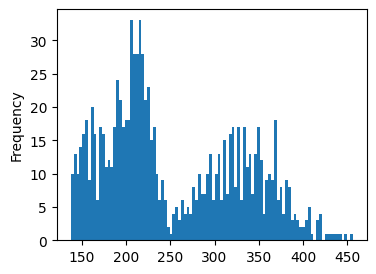

In [17]:
sr_token_length.plot.hist(bins=100, figsize=(4, 3))

<Axes: ylabel='Frequency'>

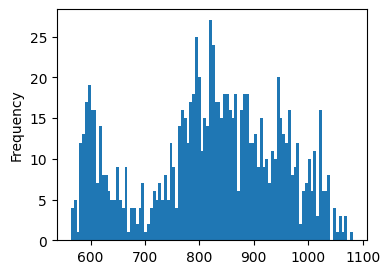

In [18]:
sr_char_length.plot.hist(bins=100, figsize=(4, 3))

In [19]:
hfds_news_sampled = hf_datasets.Dataset.from_pandas(df_news_sampled)

In [20]:
tokenizer.encode('analysis')

[35644]

In [21]:
def prepare_celoss_inputs_leftpad(
    logits: torch.Tensor,
    input_ids: torch.Tensor,
    attention_mask: torch.Tensor,
    response_token_id: int = tokenizer.encode('analysis')[0],
    loss_mask_start_pos_offset = 2,
    ignore_index = -100,
):
    """
    Prepares inputs for left-padded causal language modeling (next-token prediction) loss
    with masking applied only after the first occurrence of a response token (e.g., <|assistant|>).

    This function:
    - Shifts logits and labels for next-token prediction.
    - Applies masking to compute loss only from the assistant's response portion.
    - Handles left-padded sequences (e.g., tokenizer.padding_side = 'left').

    Args:
        logits (torch.Tensor): Raw model output logits of shape [B, T, V].
        input_ids (torch.Tensor): Input token IDs of shape [B, T].
        attention_mask (torch.Tensor): Attention mask of shape [B, T].
        response_token_id (int, optional): Token ID that marks the start of assistant response.
        loss_mask_start_pos_offset (int, optional): Offset from first response token to begin loss computation.
        ignore_index (int, optional): Label index to ignore in loss computation.

    Returns:
        logits (torch.Tensor): Transposed logits for CE loss [B, V, T-1].
        masked_labels (torch.Tensor): Labels with loss mask applied [B, T-1].
        non_masked_labels (torch.Tensor): Raw next-token labels (before masking) [B, T-1].
        label_mask (torch.BoolTensor): Boolean mask indicating where loss is computed [B, T-1].

    Raises:
        Exception: If `response_token_id` is not found in any sequence of the batch.
    """
    # Shift logits and labels for next-token prediction
    logits = logits[:, :-1, :]               # [B, T-1, V]
    labels = input_ids[:, 1:]                # [B, T-1]
    attention_mask = attention_mask[:, 1:]   # align with labels

    # Transpose logits to (B, V, T-1) for non-flattened CE loss
    logits = logits.transpose(1, 2)          # [B, V, T-1]

    # Create label mask: only compute loss on response tokens
    # Detect first response token (e.g., first BOS or special response marker)
    # response_mask = (input_ids == response_token_id).to(torch.long)  # [B, T]
    # assert (response_mask.sum(dim=-1) == 1).all()
    # first_response_positions = response_mask.argmax(dim=1) + loss_mask_start_pos_offset           # [B]
    # response_token_idが１文に複数現れる場合
    if not (input_ids == response_token_id).any(dim=1).all(): raise Exception(f"response_token_id {response_token_id} not found in some input_ids")
    first_response_positions = input_ids.size(1) - (input_ids == response_token_id).fliplr().int().argmax(dim=1) - 1
    first_response_positions += loss_mask_start_pos_offset

    # Build label_mask from first_response_positions
    B, T_1 = labels.size()
    label_mask = torch.zeros_like(labels, dtype=torch.bool)          # [B, T-1]
    for i in range(B):
        start = first_response_positions[i].item() - 1  # labels are shifted right
        if start < 0:
            continue
        label_mask[i, start:] = 1

    # Mask labels
    masked_labels = labels.clone()
    masked_labels[~label_mask] = ignore_index

    non_masked_labels = labels
    
    return logits, masked_labels, non_masked_labels, label_mask

In [22]:
def collate_fn(examples, device=device, padding_length = TEXT_PADDING_MAX_LENGTH):
    texts = [example["text"] for example in examples]
    if padding_length == None:
        input_batch = tokenizer.batch_encode_plus(texts, padding=True, return_tensors="pt").to(device)
    else:
        assert tokenizer.padding_side == 'left'
        input_batch = tokenizer.batch_encode_plus(texts, padding='max_length', max_length=padding_length, truncation=True, return_tensors="pt").to(device)

    return input_batch

In [23]:
hfds_news_sampled = hfds_news_sampled.train_test_split(test_size=0.1, shuffle=True)

In [24]:
train_dataloader = torch.utils.data.DataLoader(
    hfds_news_sampled['train'],
    shuffle=True,
    collate_fn=collate_fn,
    batch_size=TRAIN_BATCH_SIZE,
)
test_dataloader = torch.utils.data.DataLoader(
    hfds_news_sampled['test'],
    shuffle=False,
    collate_fn=collate_fn,
    batch_size=TEST_BATCH_SIZE,
)

In [25]:
_batch = next(iter(train_dataloader))

## Train

In [26]:
@torch.inference_mode()
def generate_from_prompt(hf_ds, max_new_tokens=300, suffix_prompt=''):
    orig_padding = tokenizer.padding_side
    # suffix_prompt = '<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>'
    # suffix_prompt = '<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>'
    # suffix_prompt = ''
    prompts = hf_ds['prompt']
    prompts = [p + suffix_prompt for p in prompts]
    tokenized_inputs = tokenizer.batch_encode_plus(prompts, padding=True, return_tensors="pt").to(device)
    gen_tokens = model.generate(**tokenized_inputs, max_new_tokens=max_new_tokens)
    
    tokenizer.padding_side = orig_padding  # model.generate automatically change tokenizer.padding_size to 'right', so set back to original 'left'

    # gen_texts = tokenizer.batch_decode(gen_tokens)
    # decode generated tokens with prompt part excluded
    gen_texts = [
        tokenizer.decode(gen_tokens[i][len(tokenized_inputs["input_ids"][i]):], skip_special_tokens=False)
        for i in range(len(gen_tokens))
    ]
    return gen_texts

In [27]:
def get_trainable_params(models):
    params = []
    for model in models:
        params += [p for p in model.parameters() if p.requires_grad]
    assert len(params) > 0
    return params

In [28]:
# optimizer = torch.optim.AdamW(
optimizer = bnb.optim.AdamW8bit(
    # nn.ModuleList(train_models).parameters(),
    get_trainable_params([model]),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = transformers.get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=1*len(train_dataloader),
    num_training_steps=N_EPOCHS*len(train_dataloader),
)

scaler = torch.amp.GradScaler(device=device, enabled=USE_AMP)

In [29]:
# model.gradient_checkpointing_disable()

In [30]:
%%time
loss_history = []
train_acc_history = []
test_acc_history = []

for epoch in range(N_EPOCHS):
    ############## Ealuluation Phase ##############
    model.eval()
    pred_labels = []
    true_labels = []
    metric_target_mask_list = []
    with torch.inference_mode():
        for batch in pb(test_dataloader):
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                llm_out = model(**batch)
                pred_logits = llm_out.logits
                logits_for_loss, masked_labels, non_masked_labels, label_mask = prepare_celoss_inputs_leftpad(
                    logits=pred_logits,
                    input_ids=batch['input_ids'],
                    attention_mask=batch['attention_mask'],
                )
                loss = torch.nn.functional.cross_entropy(logits_for_loss, masked_labels, ignore_index=-100)
                if torch.isnan(loss):
                    print('loss is nan')
                    raise Exception()
                pred_labels.append(logits_for_loss.argmax(1).long().cpu().detach())
                true_labels.append(non_masked_labels.cpu().detach())
                metric_target_mask_list.append((label_mask).cpu())
    pred_labels = torch.cat(pred_labels, dim=0)
    true_labels = torch.cat(true_labels, dim=0)
    metric_target_mask = torch.cat(metric_target_mask_list, dim=0)
    # acc = (pred_labels.flatten() == true_labels.flatten()).float().mean()
    acc = ((pred_labels == true_labels).long() * metric_target_mask.cpu()).sum() / metric_target_mask.sum()
    test_acc_history.append(acc)
    print(f'epoch {epoch} : test ntp acc {test_acc_history[-1]}')
    print(metric_target_mask.sum(dim=-1).float().mean())

    gt_texts = [t.replace('!', '').replace('<|reserved_200017|>', '').replace('<|return|>', '') for t in tokenizer.batch_decode(true_labels[:3] * metric_target_mask[:3])]
    pred_texts = [t.replace('!', '').replace('<|reserved_200017|>', '').replace('<|return|>', '') for t in tokenizer.batch_decode(pred_labels[:3] * metric_target_mask[:3])]
    print('test gt txt', gt_texts)
    print('test pred txt', pred_texts)

    samplegen_test_hfds = hfds_news_sampled['test'][:3]
    gen_texts = generate_from_prompt(samplegen_test_hfds, suffix_prompt='')
    for i, t in enumerate(gen_texts):
        print(f'[{i}] gen_text : \n' + t.replace('<|reserved_200017|>', '').replace('<|return|>', ''))
        print(f'[{i}] gt topic : ', samplegen_test_hfds['topic'][i])

    ############## Train phase ###############
    model.train()
    epoch_loss = 0.0
    pred_labels = []
    true_labels = []
    metric_target_mask_list = []
    for batch in pb(train_dataloader):
        optimizer.zero_grad()
        with torch.autocast(device_type=device, dtype=AMP_DTYPE, enabled=USE_AMP):
            llm_out = model(**batch)
            pred_logits = llm_out.logits
            logits_for_loss, masked_labels, non_masked_labels, label_mask = prepare_celoss_inputs_leftpad(
                logits=pred_logits,
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
            )
            loss = torch.nn.functional.cross_entropy(logits_for_loss, masked_labels, ignore_index=-100)
            if torch.isnan(loss):
                print('loss is nan')
                raise Exception()
            pred_labels.append(logits_for_loss.argmax(1).long().cpu().detach())
            true_labels.append(non_masked_labels.cpu().detach())
            metric_target_mask_list.append((label_mask).cpu())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        # loss.backward()
        # optimizer.step()
        scaler.update()
        scheduler.step()
        epoch_loss += loss.cpu().detach()
    pred_labels = torch.cat(pred_labels, dim=0)
    true_labels = torch.cat(true_labels, dim=0)
    metric_target_mask = torch.cat(metric_target_mask_list, dim=0)
    # acc = (pred_labels.flatten() == true_labels.flatten()).float().mean()
    acc = ((pred_labels == true_labels).long() * metric_target_mask.cpu()).sum() / metric_target_mask.sum()
    train_acc_history.append(acc)
    loss_history.append(epoch_loss / len(train_dataloader))
    print(f'epoch {epoch} : loss {loss_history[-1]} : ntp acc {acc}')
    print(metric_target_mask.sum(dim=-1).float().mean())

    gt_texts = [t.replace('!', '').replace('<|reserved_200017|>', '').replace('<|return|>', '') for t in tokenizer.batch_decode(true_labels[:3] * metric_target_mask[:3])]
    pred_texts = [t.replace('!', '').replace('<|reserved_200017|>', '').replace('<|return|>', '') for t in tokenizer.batch_decode(pred_labels[:3] * metric_target_mask[:3])]
    print('train gt txt', gt_texts)
    print('train pred txt', pred_texts)

    print(scheduler.get_lr(), tokenizer.padding_side)

epoch 0 : test ntp acc 0.39913418889045715
tensor(11.5500)
test gt txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：technology', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world en']
test pred txt ['We<|start|>assistant<|channel|>comment<|message|>交通名交通\n\n', 'We<|start|>assistant<|channel|>comment<|message|>スポ名スポ\n\n', 'We<|start|>assistant<|channel|>analysis<|message|>Politics:政治 news politics']
[0] gen_text : 
<|channel|>analysis<|message|>We need to read the news text. The input: 
"ニュース：【交通影響 11日】一般車両 通行できない区間も  nhk.or.jp被災地ボランティア「控えて」 二次被害の恐れと石川県知事 ｜ 共同通信  共同通信七尾ＩＣまで通行止め解除 能越道｜北日本新聞webunプラス  北日本新聞社 webun【能登半島地震】道路通行止め・物流の影響：中日新聞Web  中日新聞【交通影響 10日】一般車両 通行できない区間も  nhk.or.jp"

This is about "交通" (traffic) impact due to earthquake. So category maybe "災害" or "事故・災害" maybe "災害ニュース". Also categories in Japanese: 交通, 災害, 天気? The article mentions "道路通行止め・物流の影響" "能登半島地震". So category: 災害. But the

epoch 0 : loss 1.15625 : ntp acc 0.8258536458015442
tensor(11.3889)
train gt txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：sports', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：entertainment']
train pred txt ['We<|start|>assistant<|channel|>analysis<|message|>政治:政治 news', 'We<|start|>assistant<|channel|>analysis<|message|>スポ:スポ\n\n', 'We<|start|>assistant<|channel|>analysis<|message|>Entertainment:エertainment\n\n']
[0.0001] left


epoch 1 : test ntp acc 0.9748917818069458
tensor(11.5500)
test gt txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：technology', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world en']
test pred txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：b', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：pol en']
[0] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation
[0] gt topic :  NATION
[1] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation en
[1] gt topic :  TECHNOLOGY
[2] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：polictics<|end|><|start|>assistant<|channel|>commentary<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message

epoch 1 : loss 0.07568359375 : ntp acc 0.9744390249252319
tensor(11.3889)
train gt txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world en', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：entertainment', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world en']
train pred txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：b en', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：entertainment', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world en']
[9.698463103929542e-05] left


epoch 2 : test ntp acc 0.9818181991577148
tensor(11.5500)
test gt txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：technology', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world en']
test pred txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：b', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：pol en']
[0] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：national
[0] gt topic :  NATION
[1] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：entertainment
[1] gt topic :  TECHNOLOGY
[2] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：polictics en
[2] gt topic :  WORLD_EN


...

epoch 7 : loss 0.00113677978515625 : ntp acc 0.9999024271965027
tensor(11.3889)
train gt txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：bussiness en', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：technology', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world en']
train pred txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：bussiness en', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：technology', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world en']
[1.1697777844051105e-05] left


epoch 8 : test ntp acc 0.984415590763092
tensor(11.5500)
test gt txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：technology', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world en']
test pred txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：pol', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation en']
[0] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation
[0] gt topic :  NATION
[1] gen_text : 
<|channel|>final<|message|>カテゴリ：polictics
[1] gt topic :  TECHNOLOGY
[2] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation en
[2] gt topic :  WORLD_EN


epoch 8 : loss 0.000812530517578125 : ntp acc 0.9999024271965027
tensor(11.3889)
train gt txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：technology', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation en', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：bussiness en']
train pred txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：technology', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation en', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：bussiness en']
[3.0153689607045845e-06] left


epoch 9 : test ntp acc 0.9835497736930847
tensor(11.5500)
test gt txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：technology', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world en']
test pred txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：pol', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation en']
[0] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation
[0] gt topic :  NATION
[1] gen_text : 
<|channel|>analysis<|message|>The user asks: "以下のカテゴリを教えてください." The news: "諸田玲子「登山大名」（19）  日本経済...". This is likely the "entertainment" or "sports" domain. "諸田玲子" refers to a Japanese singer, but "登山大名" likely refers to "sports" or "entertainment" news. However category: In Japanese categories: "police", "technology", "world", "domestic", "economy", "ente

epoch 9 : loss 0.000659942626953125 : ntp acc 1.0
tensor(11.3889)
train gt txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world en', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation en']
train pred txt ['<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world en', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world', '<|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation en']
[0.0] left
CPU times: user 1h 34min 41s, sys: 18min 17s, total: 1h 52min 59s
Wall time: 1h 52min 51s


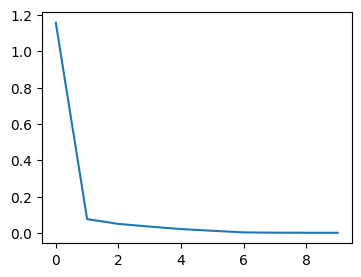

In [31]:
plt.figure(figsize=(4, 3))
plt.plot([l.item() for l in loss_history])

Text(0, 0.5, 'ntp accuracy')

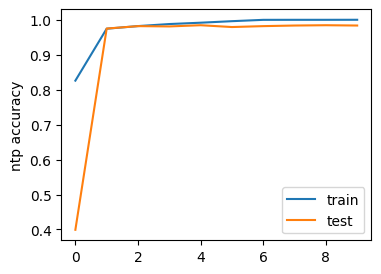

In [32]:
plt.figure(figsize=(4, 3))
plt.plot(train_acc_history, label='train')
plt.plot(test_acc_history, label='test')
plt.legend()
plt.ylabel('ntp accuracy')

## Generation with Finetuned Model

### test data

In [33]:
samplegen_test_hfds = hfds_news_sampled['test'][:6]
gen_texts = generate_from_prompt(samplegen_test_hfds, suffix_prompt='')
for i, t in enumerate(gen_texts):
    print(f'[{i}] gen_text : \n' + t.replace('<|reserved_200017|>', '').replace('<|return|>', ''))
    print(f'[{i}] gt topic : ', samplegen_test_hfds['topic'][i])
    print(100 * '=')

[0] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation
[0] gt topic :  NATION
[1] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：polictics
[1] gt topic :  TECHNOLOGY
[2] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation en
[2] gt topic :  WORLD_EN
[3] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：entertainment
[3] gt topic :  ENTERTAINMENT
[4] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：bussiness
[4] gt topic :  BUSSINESS
[5] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：entertainment
[5] gt topic :  BUSSINESS


In [34]:
samplegen_test_hfds = hfds_news_sampled['test'][:6]
gen_texts = generate_from_prompt(samplegen_test_hfds, suffix_prompt='<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>')
for i, t in enumerate(gen_texts):
    print(f'[{i}] gen_text : \n' + t.replace('<|reserved_200017|>', '').replace('<|return|>', ''))
    print(f'[{i}] gt topic : ', samplegen_test_hfds['topic'][i])
    print(100 * '=')

[0] gen_text : 
カテゴリ：nation
[0] gt topic :  NATION
[1] gen_text : 
カテゴリ：polictics
[1] gt topic :  TECHNOLOGY
[2] gen_text : 
カテゴリ：nation en
[2] gt topic :  WORLD_EN
[3] gen_text : 
カテゴリ：entertainment
[3] gt topic :  ENTERTAINMENT
[4] gen_text : 
カテゴリ：bussiness
[4] gt topic :  BUSSINESS
[5] gen_text : 
カテゴリ：entertainment
[5] gt topic :  BUSSINESS


### train data

In [35]:
samplegen_test_hfds = hfds_news_sampled['train'][:6]
gen_texts = generate_from_prompt(samplegen_test_hfds, suffix_prompt='')
for i, t in enumerate(gen_texts):
    print(f'[{i}] gen_text : \n' + t.replace('<|reserved_200017|>', '').replace('<|return|>', ''))
    print(f'[{i}] gt topic : ', samplegen_test_hfds['topic'][i])
    print(100 * '=')

[0] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：bussiness en
[0] gt topic :  BUSSINESS_EN
[1] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：entertainment
[1] gt topic :  ENTERTAINMENT
[2] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：nation en
[2] gt topic :  NATION_EN
[3] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：polictics en
[3] gt topic :  POLICTICS_EN
[4] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：world
[4] gt topic :  WORLD
[5] gen_text : 
<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>カテゴリ：bussiness
[5] gt topic :  BUSSINESS


In [36]:
samplegen_test_hfds = hfds_news_sampled['train'][:6]
gen_texts = generate_from_prompt(samplegen_test_hfds, suffix_prompt='<|channel|>analysis<|message|><|end|><|start|>assistant<|channel|>final<|message|>')
for i, t in enumerate(gen_texts):
    print(f'[{i}] gen_text : \n' + t.replace('<|reserved_200017|>', '').replace('<|return|>', ''))
    print(f'[{i}] gt topic : ', samplegen_test_hfds['topic'][i])
    print(100 * '=')

[0] gen_text : 
カテゴリ：bussiness en
[0] gt topic :  BUSSINESS_EN
[1] gen_text : 
カテゴリ：entertainment
[1] gt topic :  ENTERTAINMENT
[2] gen_text : 
カテゴリ：nation en
[2] gt topic :  NATION_EN
[3] gen_text : 
カテゴリ：polictics en
[3] gt topic :  POLICTICS_EN
[4] gen_text : 
カテゴリ：world
[4] gt topic :  WORLD
[5] gen_text : 
カテゴリ：bussiness
[5] gt topic :  BUSSINESS


---

GPU memory ~ 19GB (batch size 4)